# 🧬 Chromosome Classification — MobileNetV2 + EfficientNetB0
**Run this after your CIRNet+ResNet50 notebook. Uses the same BioImLAB dataset, same split (SEED=42), same CDA pipeline, and the same two-phase training strategy — just with two lighter, faster backbones.**

MobileNetV2 and EfficientNetB0 have far fewer parameters/FLOPs than InceptionResNetV2 and ResNet50, so each epoch runs noticeably faster on the same T4 GPU even with identical `steps_per_epoch`.

In [1]:
# Cell 0 — GPU setup (run first)
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for g in gpus:
        tf.config.experimental.set_memory_growth(g, True)
    print(f'✅ GPU found: {gpus[0]}')
else:
    print('❌ No GPU')

tf.keras.mixed_precision.set_global_policy('mixed_float16')
print(f'✅ Policy: {tf.keras.mixed_precision.global_policy().name}')

with tf.device('/GPU:0'):
    x = tf.constant([[1.0, 2.0]])
    y = tf.matmul(x, tf.transpose(x))
    print(f'✅ GPU test: {y.numpy()}')

✅ GPU found: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
✅ Policy: mixed_float16
✅ GPU test: [[5.]]


In [2]:
# Cell 1 — Setup: Kaggle dataset (skip if already downloaded in this runtime)
import os
from google.colab import files

if not os.path.exists('/content/bioimlab/Class_1'):
    uploaded = files.upload()
    uploaded_name = list(uploaded.keys())[0]
    os.makedirs('/root/.kaggle', exist_ok=True)
    with open('/root/.kaggle/kaggle.json', 'wb') as f:
        f.write(uploaded[uploaded_name])
    os.chmod('/root/.kaggle/kaggle.json', 0o600)
    !pip install -q kaggle tensorflow scikit-learn matplotlib seaborn
    !kaggle datasets download \
        -d arifmpthesis/bioimlab-chromosome-data-set-for-classification \
        --path /content/bioimlab --unzip -q
    print('✅ Dataset downloaded')
else:
    print('✅ Dataset already exists')

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/arifmpthesis/bioimlab-chromosome-data-set-for-classification
License(s): other
✅ Dataset downloaded


In [3]:
# Cell 2 — Imports + Config (identical constants/SEED to CIRNet+ResNet50 notebook
# so the train/val/test split reproduces exactly and probs line up for ensembling)
import os, re, random, warnings, time, json
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score,
                              precision_score, recall_score,
                              confusion_matrix, classification_report)
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for g in gpus:
        tf.config.experimental.set_memory_growth(g, True)
    print(f'✅ GPU: {gpus[0].name}')
else:
    print('❌ No GPU detected')

tf.keras.mixed_precision.set_global_policy('mixed_float16')
print(f'✅ Policy: {tf.keras.mixed_precision.global_policy().name}')

# Config — same IMG_SIZE/BATCH as before; lighter backbones so epochs run faster
IMG_SIZE       = 224
BATCH_SIZE     = 64
NUM_CLASSES    = 24
EPOCHS_P1      = 8          # slightly shorter — lighter backbones converge quicker
EPOCHS_P2      = 20
LR_P1          = 1e-3
DROPOUT        = 0.40
L2_REG         = 1e-4
LABEL_SMOOTH   = 0.05
CONF_THRESHOLD = 0.65
PATIENCE       = 15

CLASS_NAMES = [str(i) for i in range(1, 23)] + ['X', 'Y']
AUTOTUNE    = tf.data.AUTOTUNE
OUTPUT_DIR  = '/content'
SAVE_DIR    = '/content/drive/MyDrive/chromosome_models'

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'✅ Config ready | IMG_SIZE={IMG_SIZE} | BATCH={BATCH_SIZE}')

✅ GPU: /physical_device:GPU:0
✅ Policy: mixed_float16
✅ Config ready | IMG_SIZE=224 | BATCH=64


In [4]:
# Cell 3 — Load + Balance + CDA (byte-for-byte identical logic to the CIRNet/ResNet50
# notebook, with sorted() added on filenames for deterministic ordering across runtimes)
import cv2
from collections import Counter, defaultdict

BIOIMLAB_DIR = '/content/bioimlab'
NUM_CLASSES  = 24
CLASS_NAMES  = [str(i) for i in range(1, 23)] + ['X', 'Y']
STORE_SIZE   = 64

all_records   = []
found_classes = set()

for cls_folder in sorted(os.listdir(BIOIMLAB_DIR)):
    cls_path = os.path.join(BIOIMLAB_DIR, cls_folder)
    if not os.path.isdir(cls_path): continue
    suffix = cls_folder.split('_')[-1].upper()
    if suffix == 'X':   lbl = 22
    elif suffix == 'Y': lbl = 23
    else:
        try:    lbl = int(suffix) - 1
        except: continue
    if not (0 <= lbl < 24): continue
    for fname in sorted(os.listdir(cls_path)):
        if fname.lower().endswith(('.jpg','.jpeg','.png','.bmp')):
            all_records.append((os.path.join(cls_path, fname), lbl))
    found_classes.add(lbl)

print(f'✅ Raw: {len(all_records)} | Classes: {len(found_classes)}/24')

MAX_PER_CLASS = 200
MIN_TARGET    = 150
random.shuffle(all_records)
balanced = []
count    = defaultdict(int)

for fp, lbl in all_records:
    if count[lbl] < MAX_PER_CLASS:
        balanced.append((fp, lbl))
        count[lbl] += 1

for cls_idx in range(24):
    cls_recs = [(fp, lbl) for fp, lbl in balanced if lbl == cls_idx]
    if not cls_recs: continue
    while count[cls_idx] < MIN_TARGET:
        balanced.append(random.choice(cls_recs))
        count[cls_idx] += 1

all_records = balanced
print(f'   After balancing: {len(all_records)} images')

fps    = [r[0] for r in all_records]
labels = [r[1] for r in all_records]

fps_tv, fps_test, lbl_tv, lbl_test = train_test_split(
    fps, labels, test_size=0.15, random_state=SEED, stratify=labels)
fps_train, fps_val, lbl_train, lbl_val = train_test_split(
    fps_tv, lbl_tv, test_size=0.176, random_state=SEED, stratify=lbl_tv)

print(f'   Train: {len(fps_train)} | Val: {len(fps_val)} | Test: {len(fps_test)}')

def load_to_ram(fps, lbls, desc):
    imgs, kept = [], []
    for i, (fp, lbl) in enumerate(zip(fps, lbls)):
        if i % 300 == 0: print(f'  {desc}: {i}/{len(fps)}', end='\r')
        img = cv2.imread(fp)
        if img is None: continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (STORE_SIZE, STORE_SIZE))
        imgs.append(img)
        kept.append(lbl)
    print(f'  {desc}: done ({len(imgs)} images)        ')
    return np.array(imgs, dtype=np.uint8), np.array(kept, dtype=np.int32)

print('Loading into RAM...')
X_train_orig, y_train_orig = load_to_ram(fps_train, lbl_train, 'Train')
X_val,        y_val        = load_to_ram(fps_val,   lbl_val,   'Val')
X_test,       y_test_arr   = load_to_ram(fps_test,  lbl_test,  'Test')
lbl_test = y_test_arr.tolist()

ram_orig = (X_train_orig.nbytes + X_val.nbytes + X_test.nbytes) / 1e9
print(f'   Originals RAM: {ram_orig:.2f} GB')

CDA_ANGLES = list(range(30, 360, 30))   # 11 angles at 30° steps — same as before
print(f'\nApplying CDA ({len(CDA_ANGLES)} angles)...')

X_list = [X_train_orig]
y_list = [y_train_orig]

h, w   = STORE_SIZE, STORE_SIZE
cx, cy = w // 2, h // 2

for angle in CDA_ANGLES:
    M        = cv2.getRotationMatrix2D((cx, cy), float(angle), 1.0)
    rotated  = np.array([
        cv2.warpAffine(img, M, (w, h),
                       flags=cv2.INTER_LINEAR,
                       borderMode=cv2.BORDER_REFLECT_101)
        for img in X_train_orig
    ], dtype=np.uint8)
    X_list.append(rotated)
    y_list.append(y_train_orig)

X_train = np.concatenate(X_list, axis=0)
y_train = np.concatenate(y_list, axis=0)

idx     = np.random.permutation(len(X_train))
X_train = X_train[idx]
y_train = y_train[idx]

cls_wts = compute_class_weight('balanced',
                                classes=np.arange(24),
                                y=y_train_orig)
class_weight_dict = dict(enumerate(cls_wts))

steps   = len(X_train) // BATCH_SIZE

total_ram = (X_train.nbytes + X_val.nbytes + X_test.nbytes) / 1e9
print(f'✅ CDA done!')
print(f'   X_train : {X_train.shape}  ({total_ram:.2f} GB total RAM)')
print(f'   Steps/epoch: {steps}')

import psutil
ram_used = psutil.virtual_memory().used / 1e9
ram_total= psutil.virtual_memory().total / 1e9
print(f'   System RAM: {ram_used:.1f} / {ram_total:.1f} GB used')
if ram_used > 10:
    print('⚠️  RAM high — consider restarting and reducing BATCH_SIZE')
else:
    print('✅ RAM OK')

✅ Raw: 5474 | Classes: 24/24
   After balancing: 4743 images
   Train: 3321 | Val: 710 | Test: 712
Loading into RAM...
  Train: done (3321 images)        
  Val: done (710 images)        
  Test: done (712 images)        
   Originals RAM: 0.06 GB

Applying CDA (11 angles)...
✅ CDA done!
   X_train : (39852, 64, 64, 3)  (0.51 GB total RAM)
   Steps/epoch: 622
   System RAM: 3.0 / 13.6 GB used
✅ RAM OK


In [5]:
# Cell 4 — tf.data Pipeline (RAM arrays, no disk I/O during training)
from tensorflow.keras.applications.mobilenet_v2 import (
    preprocess_input as mobilenet_preprocess)
from tensorflow.keras.applications.efficientnet import (
    preprocess_input as efficientnet_preprocess)

AUTOTUNE = tf.data.AUTOTUNE

def make_dataset_from_arrays(X, y, preprocess_fn, training=True):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(len(X), seed=SEED, reshuffle_each_iteration=True)

    def process(img, lbl):
        img = tf.cast(img, tf.float32)
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
        img = preprocess_fn(img)
        return img, tf.one_hot(lbl, NUM_CLASSES)

    def augment(img, lbl):
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        k   = tf.random.uniform([], 0, 4, dtype=tf.int32)
        img = tf.image.rot90(img, k)
        img = tf.image.random_brightness(img, max_delta=0.05)
        return img, lbl

    ds = ds.batch(BATCH_SIZE)
    ds = ds.map(lambda x, y: process(x, y), num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

mobilenet_train_ds = make_dataset_from_arrays(X_train, y_train, mobilenet_preprocess, training=True)
mobilenet_val_ds   = make_dataset_from_arrays(X_val,   y_val,   mobilenet_preprocess, training=False)
mobilenet_test_ds  = make_dataset_from_arrays(X_test,  y_test_arr, mobilenet_preprocess, training=False)

efficientnet_train_ds = make_dataset_from_arrays(X_train, y_train, efficientnet_preprocess, training=True)
efficientnet_val_ds   = make_dataset_from_arrays(X_val,   y_val,   efficientnet_preprocess, training=False)
efficientnet_test_ds  = make_dataset_from_arrays(X_test,  y_test_arr, efficientnet_preprocess, training=False)

import time
t0 = time.time()
for imgs, lbls in mobilenet_train_ds.take(3):
    pass
elapsed = time.time() - t0
print(f'✅ Pipeline ready')
print(f'   3 batches took: {elapsed:.2f}s')
print(f'   Shape: {imgs.shape}')
print(f'   Steps/epoch: {steps}')

✅ Pipeline ready
   3 batches took: 1.64s
   Shape: (64, 224, 224, 3)
   Steps/epoch: 622


In [6]:
# Cell 5 — Model Builder (same head architecture as CIRNet/ResNet50 for fair comparison)
def build_head(backbone_out, name_prefix):
    x = layers.GlobalAveragePooling2D(name=f'{name_prefix}_gap')(backbone_out)
    x = layers.BatchNormalization(name=f'{name_prefix}_bn1')(x)
    x = layers.Dropout(DROPOUT, name=f'{name_prefix}_drop1')(x)
    x = layers.Dense(
        512, use_bias=False,
        kernel_initializer='he_uniform',
        kernel_regularizer=regularizers.l2(L2_REG),
        name=f'{name_prefix}_fc1'
    )(x)
    x = layers.BatchNormalization(name=f'{name_prefix}_bn2')(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(DROPOUT * 0.75, name=f'{name_prefix}_drop2')(x)
    out = layers.Dense(
        NUM_CLASSES, activation='softmax',
        kernel_initializer='glorot_uniform',
        dtype='float32', name=f'{name_prefix}_output'
    )(x)
    return out

def build_mobilenet():
    inp  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    base = MobileNetV2(
        include_top=False, weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False
    x   = base(inp, training=False)
    out = build_head(x, name_prefix='mnv2_')
    return Model(inp, out, name='MobileNetV2'), base

def build_efficientnet():
    inp  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    base = EfficientNetB0(
        include_top=False, weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False
    x   = base(inp, training=False)
    out = build_head(x, name_prefix='eff_')
    return Model(inp, out, name='EfficientNetB0'), base

mobilenet_model,     mobilenet_backbone     = build_mobilenet()
efficientnet_model,  efficientnet_backbone  = build_efficientnet()

for name, m in [('MobileNetV2', mobilenet_model), ('EfficientNetB0', efficientnet_model)]:
    total    = sum(v.numpy().size for v in m.weights) / 1e6
    trainable= sum(v.numpy().size for v in m.trainable_weights) / 1e6
    print(f'✅ {name}: {total:.1f}M total | {trainable:.2f}M trainable (Phase 1)')

print(f'\nDatasets ready:')
print(f'  X_train : {X_train.shape}  Steps/epoch: {steps}')
print(f'  X_val   : {X_val.shape}')
print(f'  X_test  : {X_test.shape}')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ MobileNetV2: 2.9M total | 0.67M trainable (Phase 1)
✅ EfficientNetB0: 4.7M total | 0.67M trainable (Phase 1)

Datasets ready:
  X_train : (39852, 64, 64, 3)  Steps/epoch: 622
  X_val   : (710, 64, 64, 3)
  X_test  : (712, 64, 64, 3)


In [7]:
# Cell 6 — Training Function (identical strategy to CIRNet/ResNet50 notebook)
def train_model(model, model_name, backbone, unfreeze_from,
                train_ds, val_ds):

    ckpt    = f'{OUTPUT_DIR}/{model_name}_best.keras'
    loss_fn = keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH)

    print(f'\n{"="*55}')
    print(f'  {model_name} — PHASE 1 (frozen backbone)')
    print(f'  Steps/epoch: {steps}')
    print(f'{"="*55}')
    backbone.trainable = False

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LR_P1),
        loss=loss_fn,
        metrics=['accuracy']
    )
    cb_p1 = [
        keras.callbacks.ModelCheckpoint(
            ckpt, monitor='val_accuracy',
            save_best_only=True, verbose=1),
        keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=8,
            restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=4, min_lr=1e-7, verbose=1),
    ]
    h1 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_P1,
        steps_per_epoch=steps,
        callbacks=cb_p1,
        class_weight=class_weight_dict,
        verbose=1
    )
    p1_best = max(h1.history['val_accuracy']) * 100
    print(f'\n✅ Phase 1 best val_acc: {p1_best:.2f}%')

    print(f'\n{"="*55}')
    print(f'  {model_name} — PHASE 2 (fine-tuning top layers)')
    print(f'{"="*55}')

    backbone.trainable = True
    reached  = False
    n_frozen = 0
    for layer in backbone.layers:
        if unfreeze_from in layer.name:
            reached = True
        if not reached:
            layer.trainable = False
            n_frozen += 1
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    print(f'   Frozen layers: {n_frozen}')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0),
        loss=loss_fn,
        metrics=['accuracy']
    )
    cb_p2 = [
        keras.callbacks.ModelCheckpoint(
            ckpt, monitor='val_accuracy',
            save_best_only=True, verbose=1),
        keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=15,
            restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=5, min_lr=1e-8, verbose=1),
    ]
    h2 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_P2,
        steps_per_epoch=steps,
        callbacks=cb_p2,
        class_weight=class_weight_dict,
        verbose=1
    )
    p2_best = max(h2.history['val_accuracy']) * 100
    print(f'\n✅ Phase 2 best val_acc: {p2_best:.2f}%')
    model.load_weights(ckpt)
    return h1, h2

In [8]:
# Cell 7 — Train MobileNetV2
# MobileNetV2 has ~155 layers; unfreezing from block_13 fine-tunes roughly the top third
MOBILENET_UNFREEZE = 'block_13_expand'
mobilenet_h1, mobilenet_h2 = train_model(
    mobilenet_model, 'MobileNetV2', mobilenet_backbone, MOBILENET_UNFREEZE,
    mobilenet_train_ds, mobilenet_val_ds
)
print('✅ MobileNetV2 training complete')


  MobileNetV2 — PHASE 1 (frozen backbone)
  Steps/epoch: 622
Epoch 1/8
622/622 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.2615 - loss: 2.6303
Epoch 1: val_accuracy improved from None to 0.37183, saving model to /content/MobileNetV2_best.keras

Epoch 1: finished saving model to /content/MobileNetV2_best.keras
622/622 ━━━━━━━━━━━━━━━━━━━━ 229s 293ms/step - accuracy: 0.3221 - loss: 2.3686 - val_accuracy: 0.3718 - val_loss: 2.1500 - learning_rate: 0.0010
Epoch 2/8
  1/622 ━━━━━━━━━━━━━━━━━━━━ 6:02:57 35s/step - accuracy: 0.3864 - loss: 2.1987
Epoch 2: val_accuracy did not improve from 0.37183
622/622 ━━━━━━━━━━━━━━━━━━━━ 36s 1ms/step - accuracy: 0.3864 - loss: 2.1987 - val_accuracy: 0.3662 - val_loss: 2.1485 - learning_rate: 0.0010
Epoch 3/8
622/622 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.4012 - loss: 2.0964
Epoch 3: val_accuracy improved from 0.37183 to 0.41549, saving model to /content/MobileNetV2_best.keras

Epoch 3: finished saving model to /content/MobileNetV2_best.ker

In [9]:
# Cell 8 — Train EfficientNetB0
# EfficientNetB0 blocks run 1–7; unfreezing from block6a fine-tunes the last two blocks
EFFICIENTNET_UNFREEZE = 'block6a'
efficientnet_h1, efficientnet_h2 = train_model(
    efficientnet_model, 'EfficientNetB0', efficientnet_backbone, EFFICIENTNET_UNFREEZE,
    efficientnet_train_ds, efficientnet_val_ds
)
print('✅ EfficientNetB0 training complete')


  EfficientNetB0 — PHASE 1 (frozen backbone)
  Steps/epoch: 622
Epoch 1/8
621/622 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.2618 - loss: 2.6341
Epoch 1: val_accuracy improved from None to 0.43662, saving model to /content/EfficientNetB0_best.keras

Epoch 1: finished saving model to /content/EfficientNetB0_best.keras
622/622 ━━━━━━━━━━━━━━━━━━━━ 253s 297ms/step - accuracy: 0.3269 - loss: 2.3647 - val_accuracy: 0.4366 - val_loss: 2.0342 - learning_rate: 0.0010
Epoch 2/8
  1/622 ━━━━━━━━━━━━━━━━━━━━ 8:32:53 50s/step - accuracy: 0.4091 - loss: 2.1143
Epoch 2: val_accuracy did not improve from 0.43662
622/622 ━━━━━━━━━━━━━━━━━━━━ 50s 1ms/step - accuracy: 0.4091 - loss: 2.1143 - val_accuracy: 0.4366 - val_loss: 2.0358 - learning_rate: 0.0010
Epoch 3/8
622/622 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.4167 - loss: 2.0764
Epoch 3: val_accuracy improved from 0.43662 to 0.47606, saving model to /content/EfficientNetB0_best.keras

Epoch 3: finished saving model to /content/Efficien


  MobileNetV2 — TEST RESULTS
  Accuracy  : 81.04%
  Precision : 0.8214
  Recall    : 0.8123
  F1 Macro  : 0.8127


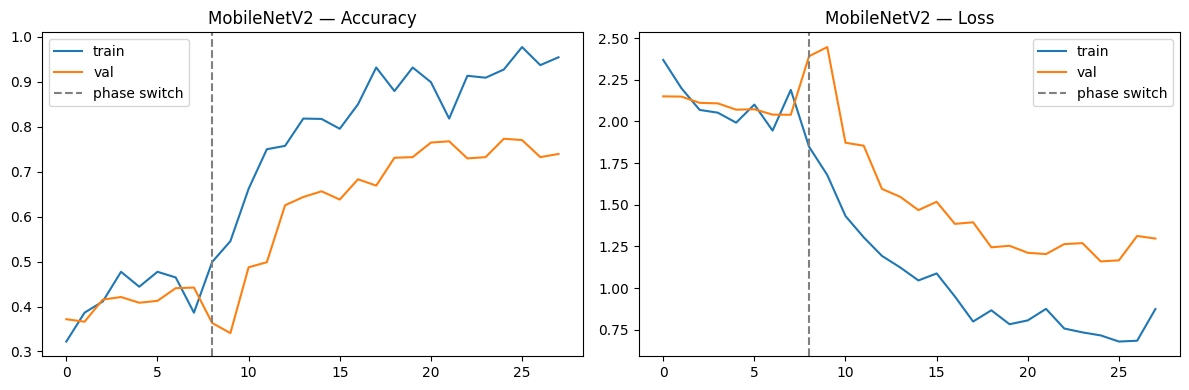

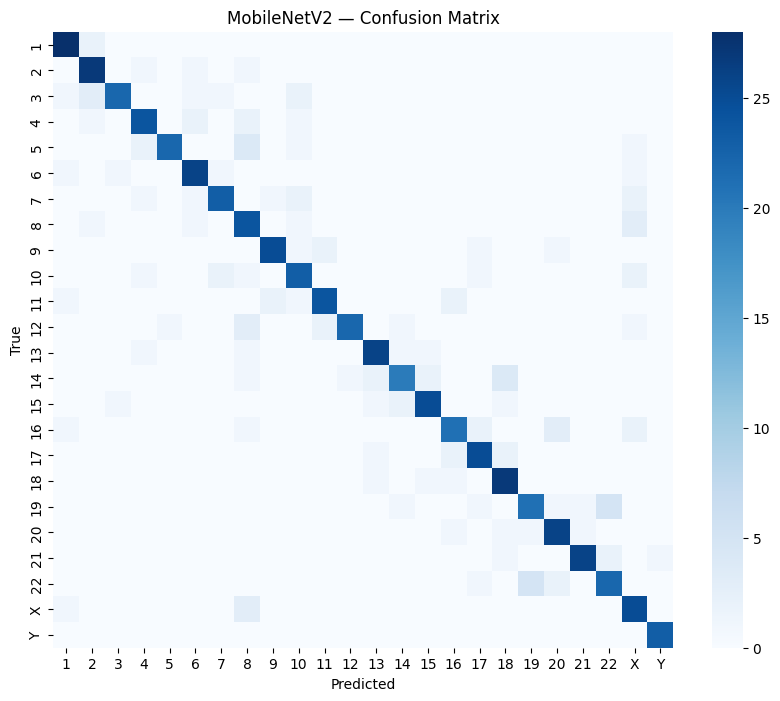

✅ Saved: MobileNetV2_results.csv | curves.png | confusion.png | probs.npy

  EfficientNetB0 — TEST RESULTS
  Accuracy  : 84.97%
  Precision : 0.8588
  Recall    : 0.8511
  F1 Macro  : 0.8525


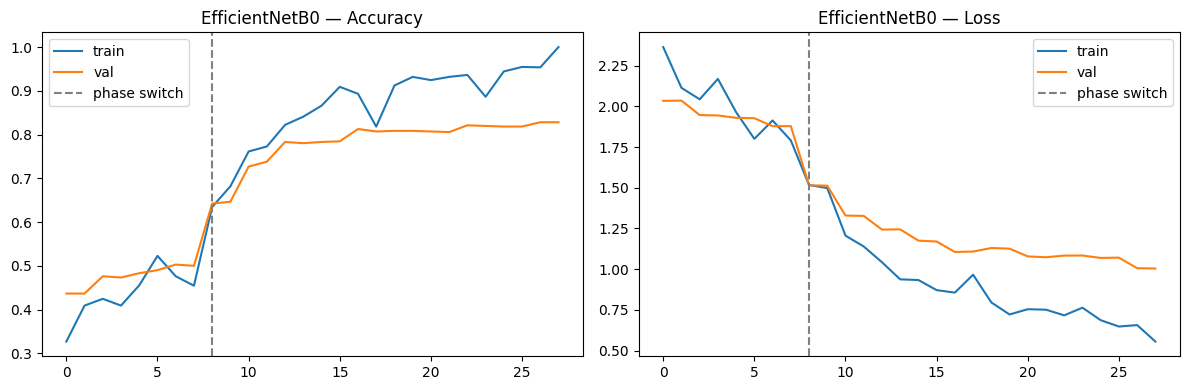

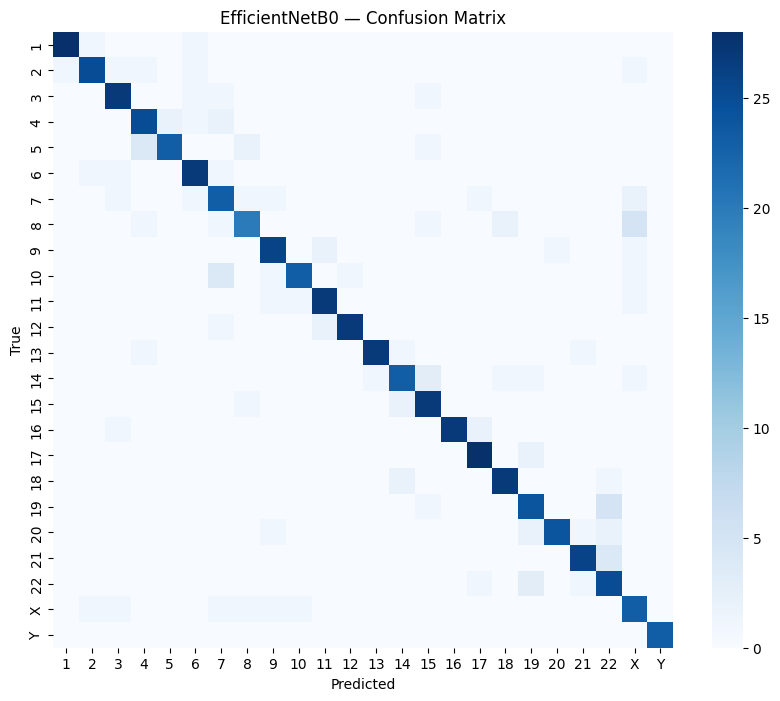

✅ Saved: EfficientNetB0_results.csv | curves.png | confusion.png | probs.npy


In [10]:
# Cell 9 — Evaluate both models (identical scoring logic to CIRNet/ResNet50 notebook)
def evaluate(model, model_name, test_ds, h1, h2):
    probs = model.predict(test_ds, verbose=0)
    preds = np.argmax(probs, axis=1)
    confs = np.max(probs, axis=1)
    true  = np.array(lbl_test)

    acc  = accuracy_score(true, preds) * 100
    f1   = f1_score(true, preds, average='macro', zero_division=0)
    prec = precision_score(true, preds, average='macro', zero_division=0)
    rec  = recall_score(true, preds, average='macro', zero_division=0)

    print(f'\n{"="*55}')
    print(f'  {model_name} — TEST RESULTS')
    print(f'{"="*55}')
    print(f'  Accuracy  : {acc:.2f}%')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1 Macro  : {f1:.4f}')
    print(f'{"="*55}')

    per_f1   = f1_score(true, preds, average=None, zero_division=0)
    per_prec = precision_score(true, preds, average=None, zero_division=0)
    per_rec  = recall_score(true, preds, average=None, zero_division=0)
    pred_c   = Counter(preds.tolist())
    true_c   = Counter(true.tolist())

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(h1.history['accuracy'] + h2.history['accuracy'], label='train')
    ax[0].plot(h1.history['val_accuracy'] + h2.history['val_accuracy'], label='val')
    ax[0].axvline(len(h1.history['accuracy']), color='gray', linestyle='--', label='phase switch')
    ax[0].set_title(f'{model_name} — Accuracy'); ax[0].legend()
    ax[1].plot(h1.history['loss'] + h2.history['loss'], label='train')
    ax[1].plot(h1.history['val_loss'] + h2.history['val_loss'], label='val')
    ax[1].axvline(len(h1.history['loss']), color='gray', linestyle='--', label='phase switch')
    ax[1].set_title(f'{model_name} — Loss'); ax[1].legend()
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/{model_name}_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

    cm = confusion_matrix(true, preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f'{model_name} — Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('True')
    plt.savefig(f'{OUTPUT_DIR}/{model_name}_confusion.png', dpi=150, bbox_inches='tight')
    plt.show()

    df = pd.DataFrame({
        'Chr': [f'Chr {c}' for c in CLASS_NAMES],
        'Precision': np.round(per_prec, 3),
        'Recall': np.round(per_rec, 3),
        'F1': np.round(per_f1, 3),
    })
    df.to_csv(f'{OUTPUT_DIR}/{model_name}_results.csv', index=False)
    np.save(f'{OUTPUT_DIR}/{model_name}_test_probs.npy', probs)

    print(f'✅ Saved: {model_name}_results.csv | curves.png | confusion.png | probs.npy')
    return {'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1, 'probs': probs}

mobilenet_res    = evaluate(mobilenet_model,    'MobileNetV2',    mobilenet_test_ds,    mobilenet_h1,    mobilenet_h2)
efficientnet_res = evaluate(efficientnet_model, 'EfficientNetB0', efficientnet_test_ds, efficientnet_h1, efficientnet_h2)
np.save(f'{OUTPUT_DIR}/lbl_test.npy', np.array(lbl_test))

In [11]:
# Cell 10 — 2-model ensemble (MobileNetV2 + EfficientNetB0) + comparison table
ens_probs = (mobilenet_res['probs'] + efficientnet_res['probs']) / 2
ens_preds = np.argmax(ens_probs, axis=1)
true      = np.array(lbl_test)

ens_acc  = accuracy_score(true, ens_preds) * 100
ens_f1   = f1_score(true, ens_preds, average='macro', zero_division=0)
ens_prec = precision_score(true, ens_preds, average='macro', zero_division=0)
ens_rec  = recall_score(true, ens_preds, average='macro', zero_division=0)

print('\n' + '='*65)
print('  FINAL MODEL COMPARISON — MobileNetV2 / EfficientNetB0')
print('='*65)
rows = [
    {'Model':'MobileNetV2',    'Accuracy':f"{mobilenet_res['acc']:.2f}%",    'Precision':f"{mobilenet_res['prec']:.4f}",    'Recall':f"{mobilenet_res['rec']:.4f}",    'F1':f"{mobilenet_res['f1']:.4f}"},
    {'Model':'EfficientNetB0', 'Accuracy':f"{efficientnet_res['acc']:.2f}%", 'Precision':f"{efficientnet_res['prec']:.4f}", 'Recall':f"{efficientnet_res['rec']:.4f}", 'F1':f"{efficientnet_res['f1']:.4f}"},
    {'Model':'Ensemble (MNV2+Eff)', 'Accuracy':f'{ens_acc:.2f}%', 'Precision':f'{ens_prec:.4f}', 'Recall':f'{ens_rec:.4f}', 'F1':f'{ens_f1:.4f}'},
]
df_cmp = pd.DataFrame(rows)
print(df_cmp.to_string(index=False))
print('='*65)
df_cmp.to_csv(f'{OUTPUT_DIR}/mobilenet_eff_comparison.csv', index=False)
print('✅ Done — this pair combines with the CIRNet/ResNet50 notebook in the 4-model ensemble notebook next')


  FINAL MODEL COMPARISON — MobileNetV2 / EfficientNetB0
              Model Accuracy Precision Recall     F1
        MobileNetV2   81.04%    0.8214 0.8123 0.8127
     EfficientNetB0   84.97%    0.8588 0.8511 0.8525
Ensemble (MNV2+Eff)   87.08%    0.8750 0.8720 0.8721
✅ Done — this pair combines with the CIRNet/ResNet50 notebook in the 4-model ensemble notebook next


In [12]:
# Cell 11 — Save everything to Google Drive (same SAVE_DIR as CIRNet/ResNet50 notebook,
# so the 4-model ensemble notebook can find all four models' saved probs in one place)
from google.colab import drive
import shutil

drive.mount('/content/drive', force_remount=False)
os.makedirs(SAVE_DIR, exist_ok=True)

files_to_save = [
    'MobileNetV2_best.keras', 'EfficientNetB0_best.keras',
    'MobileNetV2_test_probs.npy', 'EfficientNetB0_test_probs.npy',
    'lbl_test.npy',
    'MobileNetV2_results.csv', 'EfficientNetB0_results.csv',
    'mobilenet_eff_comparison.csv',
    'MobileNetV2_curves.png', 'EfficientNetB0_curves.png',
    'MobileNetV2_confusion.png', 'EfficientNetB0_confusion.png',
]
for f in files_to_save:
    src = f'{OUTPUT_DIR}/{f}'
    if os.path.exists(src):
        shutil.copy(src, f'{SAVE_DIR}/{f}')
        print(f'✅ Saved: {f}')
    else:
        print(f'⚠️ Not found: {f}')
print(f'\n✅ All files saved to Drive: {SAVE_DIR}')

Mounted at /content/drive
✅ Saved: MobileNetV2_best.keras
✅ Saved: EfficientNetB0_best.keras
✅ Saved: MobileNetV2_test_probs.npy
✅ Saved: EfficientNetB0_test_probs.npy
✅ Saved: lbl_test.npy
✅ Saved: MobileNetV2_results.csv
✅ Saved: EfficientNetB0_results.csv
✅ Saved: mobilenet_eff_comparison.csv
✅ Saved: MobileNetV2_curves.png
✅ Saved: EfficientNetB0_curves.png
✅ Saved: MobileNetV2_confusion.png
✅ Saved: EfficientNetB0_confusion.png

✅ All files saved to Drive: /content/drive/MyDrive/chromosome_models
